In [2]:
import pandas as pd
df = pd.read_csv('Advertising.csv')   # or whatever your file is named
print(df.head())
print(df.columns.tolist())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Stats:
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


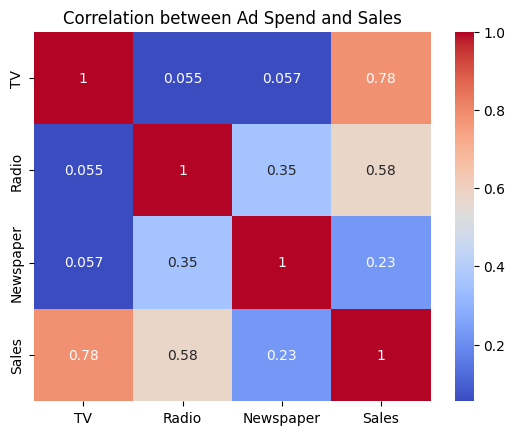

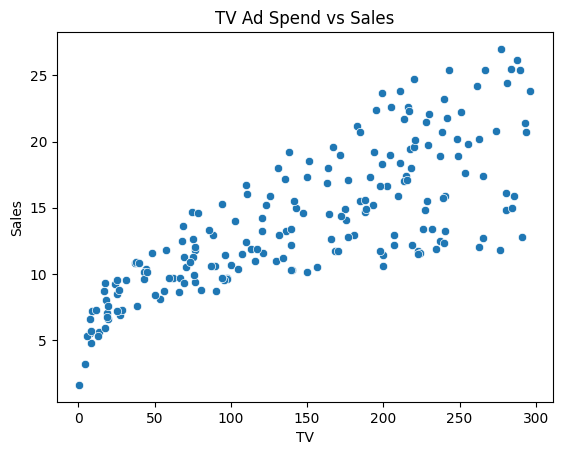

R² score : 0.899
MAE      : 1.461

Effect of each ad channel on Sales:
           Sales increase per unit spent
TV                              0.044730
Radio                           0.189195
Newspaper                       0.002761


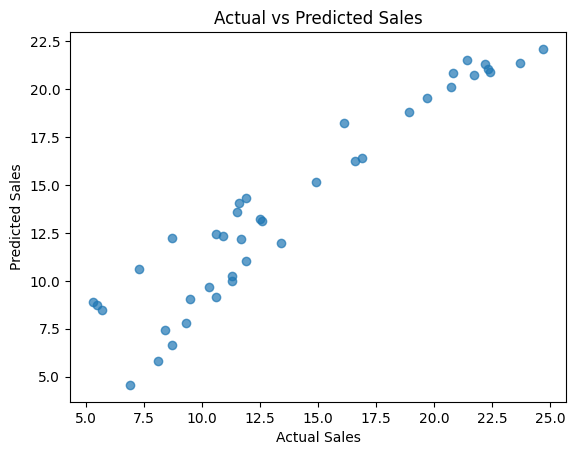

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load & clean
df = pd.read_csv('Advertising.csv')
df = df.drop(columns=['Unnamed: 0'])        # remove the useless index column
print(df.head())
print("\nMissing values:\n", df.isnull().sum())   # should be all 0
print("\nStats:\n", df.describe())

# 2. Explore: which ad channel correlates most with sales?
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Ad Spend and Sales')
plt.savefig('corr.png', bbox_inches='tight'); plt.show()

sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Ad Spend vs Sales')
plt.savefig('tv_sales.png', bbox_inches='tight'); plt.show()

# 3. Train regression model
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Evaluate
print("R² score :", round(r2_score(y_test, y_pred), 3))
print("MAE      :", round(mean_absolute_error(y_test, y_pred), 3))
print("\nEffect of each ad channel on Sales:")
print(pd.DataFrame(model.coef_, X.columns, columns=['Sales increase per unit spent']))

# 5. Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Sales'); plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.savefig('actual_vs_pred.png', bbox_inches='tight'); plt.show()

My regression model achieved an R² of 0.90. Radio has the highest per-unit return and TV the strongest overall correlation, while Newspaper spend has nearly zero effect — so the business should reallocate its Newspaper budget to TV and Radio.